In [1]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/Travel_Hospitality_Dataset.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,Column1,CANCELLED,LEAD TIME,ARRIVAL DATE YEAR,ARRIVAL DATE MONTHS,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,COUNTRY,MARKET SEGEMENT,DISTRIBUTION CHANNEL,PREVIOUS CANCELLATION,RESERVED ROOM TYPE,BOOKING CHANGES,DEPOSITE TYPE,ADDRESS,CUSTOMER TYPE
0,City Hotel,1,105,2025,February,0,8,4,0,0,GBR,Corporate,Offline,5,C,3,Refundable,211.55,Group
1,City Hotel,0,146,2025,September,2,5,1,0,0,AUS,Groups,Offline,1,A,0,Refundable,131.88,Group
2,Resort Hotel,1,200,2025,March,1,7,2,0,0,USA,Groups,Offline,2,B,1,Refundable,86.34,Contract
3,City Hotel,0,218,2025,May,3,14,3,2,0,USA,Groups,Travel Agent,5,C,0,Refundable,148.74,Contract
4,City Hotel,0,79,2025,November,0,14,2,2,1,CAN,Corporate,Online,2,B,0,No Deposit,195.43,Transient


In [3]:
# Rename 'Column1' to 'Hotel Type' and 'ADDRESS' to 'ADR'
df = df.rename(columns={'Column1': 'Hotel Type', 'ADDRESS': 'ADR'})

# Display DataFrame information to check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Hotel Type                22 non-null     object 
 1   CANCELLED                 22 non-null     int64  
 2   LEAD TIME                 22 non-null     int64  
 3   ARRIVAL DATE YEAR         22 non-null     int64  
 4   ARRIVAL DATE MONTHS       22 non-null     object 
 5   STAYS IN WEEKEND NIGHTS   22 non-null     int64  
 6   STAYS IN WEEK NIGHTS      22 non-null     int64  
 7   ADULTS                    22 non-null     int64  
 8   CHILDREN                  22 non-null     int64  
 9   BABIES                    22 non-null     int64  
 10  COUNTRY                   22 non-null     object 
 11  MARKET SEGEMENT           22 non-null     object 
 12  DISTRIBUTION CHANNEL      22 non-null     object 
 13  PREVIOUS CANCELLATION     22 non-null     int64  
 14  RESERVED ROO

In [5]:
# Ensure 'ADDRESS ' (with a trailing space) is renamed to 'ADR' if it still exists
if 'ADDRESS ' in df.columns:
    df = df.rename(columns={'ADDRESS ': 'ADR'})

# Display DataFrame information to check data types and non-null counts after renaming
df.info()

# Display the columns to explicitly verify the renaming
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Hotel Type                22 non-null     object 
 1   CANCELLED                 22 non-null     int64  
 2   LEAD TIME                 22 non-null     int64  
 3   ARRIVAL DATE YEAR         22 non-null     int64  
 4   ARRIVAL DATE MONTHS       22 non-null     object 
 5   STAYS IN WEEKEND NIGHTS   22 non-null     int64  
 6   STAYS IN WEEK NIGHTS      22 non-null     int64  
 7   ADULTS                    22 non-null     int64  
 8   CHILDREN                  22 non-null     int64  
 9   BABIES                    22 non-null     int64  
 10  COUNTRY                   22 non-null     object 
 11  MARKET SEGEMENT           22 non-null     object 
 12  DISTRIBUTION CHANNEL      22 non-null     object 
 13  PREVIOUS CANCELLATION     22 non-null     int64  
 14  RESERVED ROO

Cancellation Distribution:
CANCELLED
1    54.545455
0    45.454545
Name: proportion, dtype: float64


/tmp/ipykernel_4042/4038256064.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancellation_distribution.index, y=cancellation_distribution.values, palette='viridis')


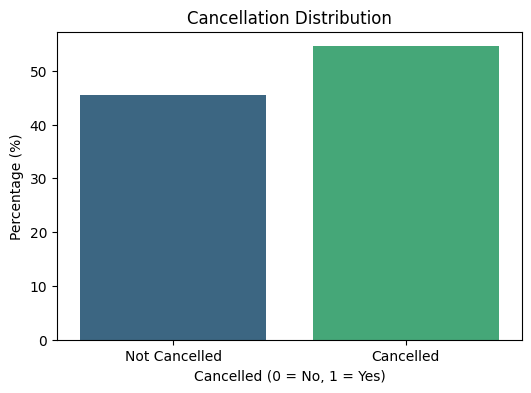

In [6]:
# Analyze the distribution of cancellations
cancellation_distribution = df['CANCELLED'].value_counts(normalize=True) * 100
print("Cancellation Distribution:")
print(cancellation_distribution)

# Visualize cancellation distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=cancellation_distribution.index, y=cancellation_distribution.values, palette='viridis')
plt.title('Cancellation Distribution')
plt.xlabel('Cancelled (0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Not Cancelled', 'Cancelled'])
plt.show()

/tmp/ipykernel_4042/1623820765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CANCELLED', y='LEAD TIME ', data=df, palette='coolwarm')


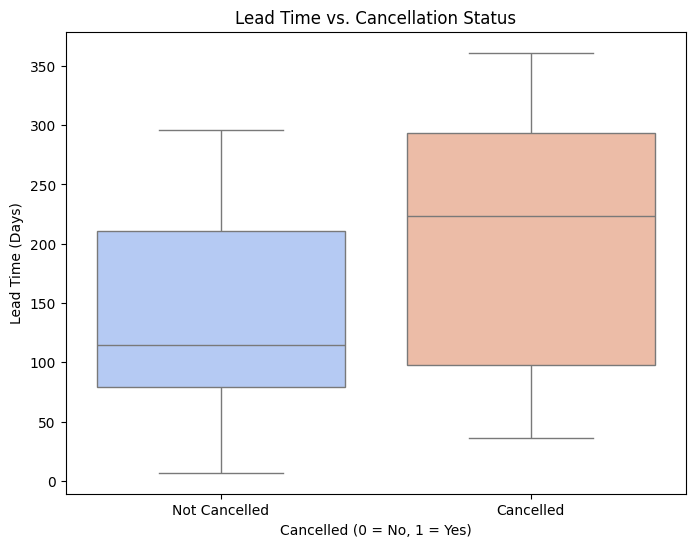

In [7]:
# Analyze 'LEAD TIME' vs. 'CANCELLED'
plt.figure(figsize=(8, 6))
sns.boxplot(x='CANCELLED', y='LEAD TIME ', data=df, palette='coolwarm')
plt.title('Lead Time vs. Cancellation Status')
plt.xlabel('Cancelled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (Days)')
plt.xticks(ticks=[0, 1], labels=['Not Cancelled', 'Cancelled'])
plt.show()

Cancellation Rate by Deposit Type:
DEPOSITE TYPE 
No Deposit    75.000000
Non Refund    33.333333
Refundable    58.333333
Name: CANCELLED, dtype: float64


/tmp/ipykernel_4042/1014403063.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deposit_cancellations.index, y=deposit_cancellations.values, palette='plasma')


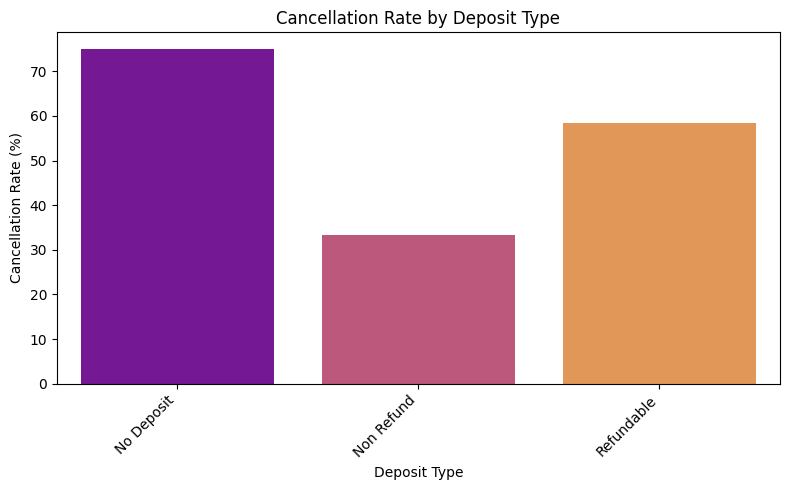

In [8]:
# Analyze 'DEPOSITE TYPE' vs. 'CANCELLED'
deposit_cancellations = df.groupby('DEPOSITE TYPE ')['CANCELLED'].mean() * 100
print("Cancellation Rate by Deposit Type:")
print(deposit_cancellations)

plt.figure(figsize=(8, 5))
sns.barplot(x=deposit_cancellations.index, y=deposit_cancellations.values, palette='plasma')
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4042/2212904094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CANCELLED', y='ADR', data=df, palette='YlGnBu')


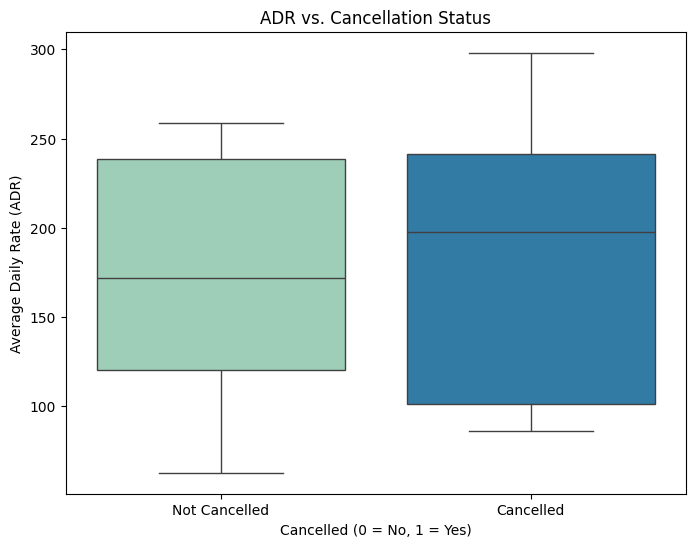

In [9]:
# Analyze 'ADR' vs. 'CANCELLED'
plt.figure(figsize=(8, 6))
sns.boxplot(x='CANCELLED', y='ADR', data=df, palette='YlGnBu')
plt.title('ADR vs. Cancellation Status')
plt.xlabel('Cancelled (0 = No, 1 = Yes)')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(ticks=[0, 1], labels=['Not Cancelled', 'Cancelled'])
plt.show()

### Data Preparation for Predictive Modeling

To build a predictive model, we need to:
1.  Clean column names by stripping trailing spaces.
2.  Encode categorical features into numerical representations.
3.  Split the data into training and testing sets.

In [10]:
# Clean column names by stripping trailing spaces
df.columns = df.columns.str.strip()

# Identify categorical columns for encoding (excluding 'CANCELLED' as it's the target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Perform one-hot encoding for categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its info
print("Encoded DataFrame head:")
display(df_encoded.head())
print("\nEncoded DataFrame Info:")
df_encoded.info()

Encoded DataFrame head:


,CANCELLED,LEAD TIME,ARRIVAL DATE YEAR,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,PREVIOUS CANCELLATION,BOOKING CHANGES,...,MARKET SEGEMENT_Online TA,DISTRIBUTION CHANNEL_Online,DISTRIBUTION CHANNEL_Travel Agent,RESERVED ROOM TYPE_B,RESERVED ROOM TYPE_C,RESERVED ROOM TYPE_D,DEPOSITE TYPE_Non Refund,DEPOSITE TYPE_Refundable,CUSTOMER TYPE_Group,CUSTOMER TYPE_Transient
0,1,105,2025,0,8,4,0,0,5,3,...,False,False,False,False,True,False,False,True,True,False
1,0,146,2025,2,5,1,0,0,1,0,...,False,False,False,False,False,False,False,True,True,False
2,1,200,2025,1,7,2,0,0,2,1,...,False,False,False,True,False,False,False,True,False,False
3,0,218,2025,3,14,3,2,0,5,0,...,False,False,True,False,True,False,False,True,False,False
4,0,79,2025,0,14,2,2,1,2,0,...,False,True,False,True,False,False,False,False,False,True



Encoded DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   CANCELLED                          22 non-null     int64  
 1   LEAD TIME                          22 non-null     int64  
 2   ARRIVAL DATE YEAR                  22 non-null     int64  
 3   STAYS IN WEEKEND NIGHTS            22 non-null     int64  
 4   STAYS IN WEEK NIGHTS               22 non-null     int64  
 5   ADULTS                             22 non-null     int64  
 6   CHILDREN                           22 non-null     int64  
 7   BABIES                             22 non-null     int64  
 8   PREVIOUS CANCELLATION              22 non-null     int64  
 9   BOOKING CHANGES                    22 non-null     int64  
 10  ADR                                22 non-null     float64
 11  Hotel Type_Resort Hotel            

In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('CANCELLED', axis=1)
y = df_encoded['CANCELLED']

# Split the data into training and testing sets
# Using a 70/30 split, with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (15, 35)
X_test shape: (7, 35)
y_train shape: (15,)
y_test shape: (7,)


### Model Training and Evaluation

Now, let's train a classification model to predict cancellations and evaluate its performance.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the Logistic Regression model
# Due to the small dataset, a higher max_iter might be needed for convergence,
# and a solver like 'liblinear' is generally robust for small datasets.
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Display feature importances (coefficients for Logistic Regression)
# It's important to understand which features the model considers most influential.
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Most Influential Features (Positive Coefficients - Increase Cancellation Likelihood):")
display(feature_importance.head(5))

print("\nTop 5 Most Influential Features (Negative Coefficients - Decrease Cancellation Likelihood):")
display(feature_importance.tail(5))

Model Accuracy: 0.7143
Model Precision: 1.0000
Model Recall: 0.5000
Model F1-Score: 0.6667

Confusion Matrix:
[[3 0]
 [2 2]]

Top 5 Most Influential Features (Positive Coefficients - Increase Cancellation Likelihood):


,Feature,Coefficient
8,BOOKING CHANGES,1.104609
23,MARKET SEGEMENT_Direct,0.437063
28,RESERVED ROOM TYPE_B,0.428672
32,DEPOSITE TYPE_Refundable,0.329814
20,COUNTRY_GBR,0.316801



Top 5 Most Influential Features (Negative Coefficients - Decrease Cancellation Likelihood):


,Feature,Coefficient
31,DEPOSITE TYPE_Non Refund,-0.260461
27,DISTRIBUTION CHANNEL_Travel Agent,-0.284142
18,ARRIVAL DATE MONTHS_September,-0.301620
25,MARKET SEGEMENT_Online TA,-0.371395
7,PREVIOUS CANCELLATION,-0.509345
